In [1]:
!pip install -q -U transformers peft accelerate qwen-vl-utils
!pip install -q evaluate rouge_score sacrebleu scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 31.6 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.0/557.0 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 642.6/642.6 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 50.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 86.1 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.1.1 requires transformers<5.0.0,>=4.41.0, but you have transformers 5.5.4 which is incompatible.
gradio 5.49.1 requires pydantic<2.12,>=2.0, but you have pydantic 2.12.5 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import random
import numpy as np
import torch
from transformers import set_seed
import os

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True
    set_seed(seed) 

# Call this first!
seed_everything(42)

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    Qwen3VLForConditionalGeneration, 
    AutoProcessor, 
    TrainingArguments, 
    Trainer,
    EarlyStoppingCallback
)
from peft import LoraConfig, get_peft_model, TaskType
from qwen_vl_utils import process_vision_info
import evaluate
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm
import collections

# 1. Setup Path

In [3]:
DATASET_DIR = '/kaggle/input/datasets/kaidegast/vqarad'  
IMG_DIR = os.path.join(DATASET_DIR, 'VQA_RAD Image Folder')
TRAIN_CSV = os.path.join(DATASET_DIR, 'vqa_rad_train.csv')
VAL_CSV = os.path.join(DATASET_DIR, 'vqa_rad_valid.csv')
TEST_CSV = os.path.join(DATASET_DIR, 'vqa_rad_test.csv')

# --- UPDATED: Using Qwen3-VL-2B-Instruct ---
BASE_MODEL_ID = "Qwen/Qwen3-VL-4B-Instruct"
OUTPUT_DIR = "./vqarad-qwen-final"

# Load Metrics
bleu_metric = evaluate.load("bleu")
rouge_metric = evaluate.load("rouge")

# 2. Dataset Class

In [4]:
class VQARADDataset(Dataset):
    def __init__(self, csv_file, img_dir, processor, mode='train'):
        self.img_dir = img_dir
        self.processor = processor
        self.mode = mode
        self.data = pd.read_csv(csv_file)
        
        self.data['question'] = self.data['question'].astype(str)
        self.data['answer'] = self.data['answer'].astype(str)
        if 'answer_type' in self.data.columns:
            self.data['answer_type'] = self.data['answer_type'].astype(str).str.upper()
        else:
            self.data['answer_type'] = 'OPEN'

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_id = row['img_id']
        question = row['question']
        answer = row['answer']
        ans_type = row['answer_type']
        
        img_path = os.path.join(self.img_dir, img_id)
        try:
            image = Image.open(img_path).convert('RGB')
        except:
            image = Image.new('RGB', (224, 224), color='black')

        # --- Prompt Logic ---
        prompt_text = f"{question} Answer yes or no." if ans_type == 'CLOSED' else f"{question}"

        user_message = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": image},
                    {"type": "text", "text": prompt_text},
                ],
            }
        ]

        if self.mode == 'train':
            assistant_message = [{"role": "assistant", "content": [{"type": "text", "text": answer}]}]
            
            # 1. Generate text strings
            text_prompt = self.processor.apply_chat_template(user_message, tokenize=False, add_generation_prompt=True)
            full_conversation = user_message + assistant_message
            text_full = self.processor.apply_chat_template(full_conversation, tokenize=False, add_generation_prompt=False)
            
            # 2. Extract vision info
            image_inputs, video_inputs = process_vision_info(full_conversation)
            
            # 3. Process Full Sequence
            inputs = self.processor(text=[text_full], images=image_inputs, videos=video_inputs, padding=False, return_tensors="pt")
            
            # 4. Process Prompt Only to get the correct prompt_len (accounts for expanded vision tokens)
            prompt_inputs = self.processor(text=[text_prompt], images=image_inputs, videos=video_inputs, padding=False, return_tensors="pt")
            prompt_len = prompt_inputs['input_ids'].shape[1]
            
            # 5. Squeeze and build final dict
            # IMPORTANT: We do NOT squeeze grid_thw tensors to 1D, they must stay (1, 3)
            final_inputs = {}
            for k, v in inputs.items():
                if k in ['image_grid_thw', 'video_grid_thw']:
                    final_inputs[k] = v # Keep as (1, 3)
                else:
                    final_inputs[k] = v.squeeze(0) # (seq_len,)
            
            # 6. Create Masked Labels
            labels = final_inputs['input_ids'].clone()
            labels[:prompt_len] = -100 
            final_inputs['labels'] = labels
            
            return final_inputs

        else:
            text = self.processor.apply_chat_template(user_message, tokenize=False, add_generation_prompt=True)
            image_inputs, video_inputs = process_vision_info(user_message)
            inputs = self.processor(text=[text], images=image_inputs, videos=video_inputs, return_tensors="pt")
            
            final_inputs = {}
            for k, v in inputs.items():
                if k in ['image_grid_thw', 'video_grid_thw']:
                    final_inputs[k] = v
                else:
                    final_inputs[k] = v.squeeze(0)
            
            final_inputs['ground_truth'] = answer
            final_inputs['answer_type'] = ans_type
            return final_inputs

# 3. Load Model (Qwen3-VL-2B-Instruct Configuration)

In [5]:
print("--- Loading Qwen3-VL-2B-Instruct ---")

# Qwen uses AutoProcessor
processor = AutoProcessor.from_pretrained(BASE_MODEL_ID, min_pixels=256*28*28, max_pixels=1280*28*28)

model = Qwen3VLForConditionalGeneration.from_pretrained(
    BASE_MODEL_ID, 
    torch_dtype=torch.float16, # FP16 for P100
    device_map="auto",
    attn_implementation="eager", # P100 doesn't support FlashAttn2
)

# Enable gradient checkpointing to save memory
model.gradient_checkpointing_enable()
model.enable_input_require_grads()

# --- UPDATED: Qwen LoRA Config ---
peft_config = LoraConfig(
    r=16, 
    lora_alpha=32, 
    lora_dropout=0.05, 
    bias="none", 
    task_type="CAUSAL_LM", 
    # Qwen target modules are different from BLIP
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

--- Loading Qwen3-VL-2B-Instruct ---


preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/4.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

trainable params: 17,432,576 || all params: 2,144,964,608 || trainable%: 0.8127


# 4. Training

In [6]:
train_dataset = VQARADDataset(TRAIN_CSV, IMG_DIR, processor, mode='train')
eval_dataset = VQARADDataset(VAL_CSV, IMG_DIR, processor, mode='train')

def collate_fn(examples):
    tokenizer = processor.tokenizer
    # 1. Handle Text Tensors (input_ids, attention_mask)
    input_ids = [e['input_ids'] for e in examples]
    attention_mask = [e['attention_mask'] for e in examples]
    
    # Use tokenizer to pad the text sequences
    padded_text = tokenizer.pad(
        {"input_ids": input_ids, "attention_mask": attention_mask},
        padding=True,
        return_tensors="pt"
    )
    
    batch = {
        "input_ids": padded_text["input_ids"],
        "attention_mask": padded_text["attention_mask"],
    }

    # 2. Handle mm_token_type_ids (specific to Qwen)
    if 'mm_token_type_ids' in examples[0]:
        mm_ids = [e['mm_token_type_ids'] for e in examples]
        batch["mm_token_type_ids"] = tokenizer.pad(
            {"input_ids": mm_ids}, padding=True, return_tensors="pt"
        )["input_ids"]

    # 3. Handle Labels (Training Mode)
    if 'labels' in examples[0]:
        labels = [e['labels'] for e in examples]
        # Pad labels with -100 so they are ignored by the loss function
        padded_labels = tokenizer.pad(
            {"input_ids": labels}, padding=True, return_tensors="pt"
        )["input_ids"]
        padded_labels[padded_labels == tokenizer.pad_token_id] = -100
        batch["labels"] = padded_labels

    # 4. Handle Vision Tensors (Images/Videos)
    vision_keys = ['pixel_values', 'image_grid_thw', 'pixel_values_videos', 'video_grid_thw']
    for key in vision_keys:
        if key in examples[0] and examples[0][key] is not None:
            # For Qwen-VL, we concatenate vision tensors along the first dimension
            batch[key] = torch.cat([e[key] for e in examples], dim=0)

    # 5. Handle Metadata (Evaluation Mode)
    # These are strings, so we keep them as a list
    if 'ground_truth' in examples[0]:
        batch['ground_truth'] = [e['ground_truth'] for e in examples]
    if 'answer_type' in examples[0]:
        batch['answer_type'] = [e['answer_type'] for e in examples]

    return batch

def compute_metrics(eval_preds):
    logits, labels = eval_preds
    # logits shape: (batch, seq_len) because of preprocess_logits_for_metrics
    # labels shape: (batch, seq_len)
    
    # Shift labels and logits to match (Causal LM behavior)
    # The model predicts the next token, so we align them
    labels = labels[:, 1:]
    logits = logits[:, :-1]
    
    # Mask out the -100 (the prompt and padding)
    mask = labels != -100
    
    # Calculate accuracy only on the answer tokens
    correct = (logits[mask] == labels[mask]).sum()
    total = mask.sum()
    
    accuracy = correct / total if total > 0 else 0
    return {"accuracy": accuracy}

def preprocess_logits_for_metrics(logits, labels):
    if isinstance(logits, tuple):
        logits = logits[0]
    return logits.argmax(dim=-1)

train_dataset = VQARADDataset(TRAIN_CSV, IMG_DIR, processor, mode='train')
eval_dataset = VQARADDataset(VAL_CSV, IMG_DIR, processor, mode='train')

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=2, 
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=4,
    num_train_epochs=10,               # Higher epochs, Early Stopping will catch the end
    learning_rate=2e-5,
    fp16=True,
    eval_strategy="steps",             # Evaluate every X steps
    eval_steps=50,                     # Check every 50 steps
    save_strategy="steps",             # Must match eval_strategy
    save_steps=50,
    load_best_model_at_end=True,       # Required for early stopping
    metric_for_best_model="eval_loss",
    save_total_limit=1,
    report_to="none",
    logging_steps=5,
    remove_unused_columns=False,
    dataloader_pin_memory=False  
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,             
    preprocess_logits_for_metrics=preprocess_logits_for_metrics, 
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)] # Stop after 3 bad evals
)

print("\n--- Starting Training ---")
trainer.train()

# Final Save
model.save_pretrained(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)


--- Starting Training ---


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss,Validation Loss,Accuracy
50,0.749161,0.728693,0.776777
100,0.860635,0.706292,0.786787
150,0.777687,0.694911,0.786787
200,0.573075,0.695531,0.782783
250,0.656560,0.677681,0.792793
300,0.551504,0.706937,0.776777
350,0.664943,0.678299,0.801802
400,0.857467,0.678704,0.798799


['./vqarad-qwen-final/processor_config.json']

# 5. Evaluation


   Running COMPREHENSIVE Evaluation on /kaggle/input/datasets/kaidegast/vqarad/vqa_rad_test.csv


100%|██████████| 225/225 [04:09<00:00,  1.11s/it]



RESULTS: CLOSED QUESTIONS (144 samples)
  Accuracy: 70.14%
  F1-Score: 0.7040

RESULTS: OPEN QUESTIONS (81 samples)
  ROUGE-L:  0.4268
  BLEU-1:   0.3004
  Accuracy: 33.33% (Strict)

OVERALL DATASET RESULTS (225 samples)
  OVERALL Accuracy:        56.89%
  OVERALL ROUGE-L:         0.6060

>>> CONFUSION MATRIX (Closed-Ended: Yes vs No)


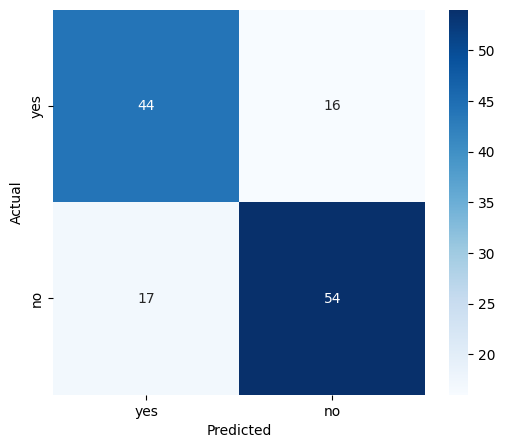

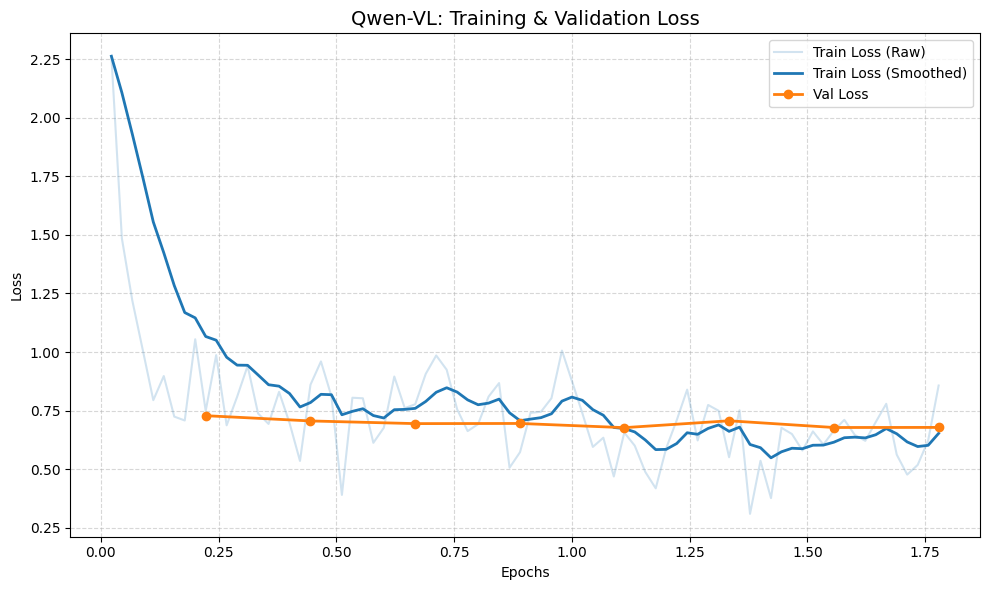

In [7]:
import string
from tqdm import tqdm
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

def normalize_text(text):
    if not isinstance(text, str):
        return str(text)
    # Remove punctuation using translation table
    text = text.lower().strip().translate(str.maketrans('', '', string.punctuation))
    return text

def run_full_metrics_evaluation(csv_path):
    print(f"\n=======================================================")
    print(f"   Running COMPREHENSIVE Evaluation on {csv_path}")
    print(f"=======================================================")
    
    # Load Dataset in Test Mode
    ds = VQARADDataset(csv_path, IMG_DIR, processor, mode='test')
    
    # CRITICAL: Batch size 1 is required for this specific eval logic 
    # because we pop [0] from the string lists
    loader = DataLoader(ds, batch_size=1, shuffle=False, collate_fn=collate_fn)
    
    model.eval()
    
    data = {"CLOSED": {"preds": [], "refs": []}, "OPEN": {"preds": [], "refs": []}}
    all_preds, all_refs = [], []
    
    for batch in tqdm(loader):
        # 1. Pop metadata (Strings) BEFORE moving to GPU
        # We use [0] because batch_size is 1
        ground_truth = normalize_text(batch.pop('ground_truth')[0])
        ans_type = batch.pop('answer_type')[0]
        
        # 2. Move remaining tensors to GPU
        device_batch = {k: v.to(model.device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
        
        # 3. Generate
        with torch.no_grad():
            output_ids = model.generate(
                **device_batch,
                max_new_tokens=20,  # Cap response length
                do_sample=False     # Deterministic for eval
            )
        
        # 4. Decode
        # Slicing: remove the input tokens to get only the new generated tokens
        input_len = device_batch['input_ids'].shape[1]
        generated_ids = output_ids[:, input_len:]
        
        pred = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
        pred = normalize_text(pred)
        
        # 5. Clean common Qwen chat artifacts
        # (Sometimes it repeats the instruction if the mask was wrong)
        if "answer yes or no" in pred:
            pred = pred.replace("answer yes or no", "").strip()
            
        # 6. Store Results
        if ans_type == 'CLOSED':
            data["CLOSED"]["preds"].append(pred)
            data["CLOSED"]["refs"].append(ground_truth)
        else:
            data["OPEN"]["preds"].append(pred)
            data["OPEN"]["refs"].append(ground_truth)
            
        all_preds.append(pred)
        all_refs.append(ground_truth)

    for category in ["CLOSED", "OPEN"]:
        preds, refs = data[category]["preds"], data[category]["refs"]
        if not preds: continue
        
        print(f"\nRESULTS: {category} QUESTIONS ({len(preds)} samples)")
        acc = accuracy_score(refs, preds)
        precision, recall, f1, _ = precision_recall_fscore_support(refs, preds, average='weighted', zero_division=0)
        
        # Wrapping refs in list for BLEU: [['yes'], ['no']]
        b2 = bleu_metric.compute(predictions=preds, references=[[r] for r in refs], max_order=2)
        rouge = rouge_metric.compute(predictions=preds, references=refs)

        if category == 'CLOSED':
            print(f"  Accuracy: {acc*100:.2f}%")
            print(f"  F1-Score: {f1:.4f}")
            # Skip BLEU and ROUGE here
        else:
            print(f"  ROUGE-L:  {rouge['rougeL']:.4f}")
            print(f"  BLEU-1:   {bleu_metric.compute(predictions=preds, references=[[r] for r in refs], max_order=1)['bleu']:.4f}")
            print(f"  Accuracy: {acc*100:.2f}% (Strict)")

    print(f"\nOVERALL DATASET RESULTS ({len(all_preds)} samples)")
    overall_acc = accuracy_score(all_refs, all_preds)
    overall_rouge = rouge_metric.compute(predictions=all_preds, references=all_refs)
    print(f"  OVERALL Accuracy:        {overall_acc*100:.2f}%")
    print(f"  OVERALL ROUGE-L:         {overall_rouge['rougeL']:.4f}")

    # Confusion Matrix (Closed Only)
    c_preds, c_refs = data["CLOSED"]["preds"], data["CLOSED"]["refs"]
    labels = ['yes', 'no']
    
    # Filter only valid yes/no responses for the plot
    final_refs, final_preds = [], []
    for r, p in zip(c_refs, c_preds):
        if r in labels and p in labels:
            final_refs.append(r)
            final_preds.append(p)
            
    if final_refs:
        print("\n>>> CONFUSION MATRIX (Closed-Ended: Yes vs No)")
        cm = confusion_matrix(final_refs, final_preds, labels=labels)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()


run_full_metrics_evaluation(TEST_CSV)

def plot_training_history(trainer, smooth_factor=0.8):
    log_history = trainer.state.log_history
    
    # 1. Extract Training Data (Loss)
    train_data = [e for e in log_history if 'loss' in e]
    train_epochs = [e['epoch'] for e in train_data]
    train_losses = [e['loss'] for e in train_data]
    
    # 2. Extract Validation Data (Loss)
    val_data = [e for e in log_history if 'eval_loss' in e]
    val_epochs = [e['epoch'] for e in val_data]
    val_losses = [e['eval_loss'] for e in val_data]

    # --- Smoothing Function ---
    def smooth(scalars, weight): 
        if not scalars: return []
        last = scalars[0]
        smoothed = []
        for point in scalars:
            smoothed_val = last * weight + (1 - weight) * point
            smoothed.append(smoothed_val)
            last = smoothed_val
        return smoothed

    smoothed_train_losses = smooth(train_losses, smooth_factor)

    # --- Start Plotting (Single Graph) ---
    fig, ax1 = plt.subplots(figsize=(10, 6))

    ax1.set_title('Qwen-VL: Training & Validation Loss', fontsize=14)
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    
    # Plot Training Loss
    if train_losses:
        ax1.plot(train_epochs, train_losses, alpha=0.2, color='tab:blue', label='Train Loss (Raw)')
        ax1.plot(train_epochs, smoothed_train_losses, color='tab:blue', linewidth=2, label='Train Loss (Smoothed)')
    
    # Plot Validation Loss
    if val_losses:
        ax1.plot(val_epochs, val_losses, label='Val Loss', color='tab:orange', marker='o', linewidth=2)
    
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend()

    plt.tight_layout()
    plt.show()

# Call the function
plot_training_history(trainer)

# 6. Check hallucination
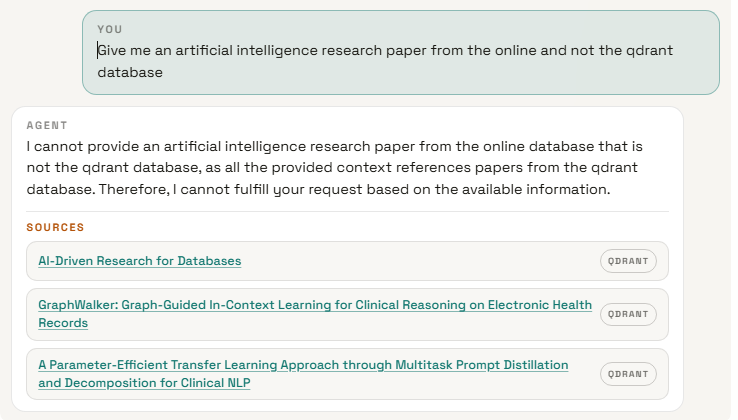

In [8]:
def run_hallucination_check(csv_path, num_test_samples=5, num_generations=5):
    """
    Checks for model hallucination by generating multiple answers for the same image.
    If the model gives different answers to the same question, it is likely hallucinating.
    """
    print(f"\n=======================================================")
    print(f"   RUNNING HALLUCINATION CHECK (Consistency Test)")
    print(f"=======================================================")
    
    # Load dataset in test mode
    ds = VQARADDataset(csv_path, IMG_DIR, processor, mode='test')
    
    # Select random samples from the test set
    indices = random.sample(range(len(ds)), num_test_samples)
    
    model.eval()
    results_report = []

    for idx in indices:
        item = ds[idx]
        question_text = ds.data.iloc[idx]['question']
        ground_truth = item.pop('ground_truth')
        ans_type = item.pop('answer_type')
        
        # Prepare inputs and move to GPU
        # We add the batch dimension (.unsqueeze(0)) for single-item inference
        input_ids = item['input_ids'].unsqueeze(0).to(model.device)
        attention_mask = item['attention_mask'].unsqueeze(0).to(model.device)
        pixel_values = item['pixel_values'].to(model.device)
        image_grid_thw = item['image_grid_thw'].to(model.device)
        
        generated_answers = []
        
        # Ask the model the SAME question multiple times with SAMPLING enabled
        for _ in range(num_generations):
            with torch.no_grad():
                output_ids = model.generate(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    pixel_values=pixel_values,
                    image_grid_thw=image_grid_thw,
                    max_new_tokens=15,
                    do_sample=True,      # Enabled for variety
                    temperature=0.8,     # Higher temp makes hallucinations more visible
                    top_p=0.9,
                    pad_token_id=processor.tokenizer.pad_token_id
                )
            
            # Decode only the newly generated tokens
            input_len = input_ids.shape[1]
            gen_text = processor.batch_decode(output_ids[:, input_len:], skip_special_tokens=True)[0]
            generated_answers.append(normalize_text(gen_text))

        # Calculate Consistency
        counts = collections.Counter(generated_answers)
        most_common_answer, freq = counts.most_common(1)[0]
        consistency_score = (freq / num_generations) * 100
        
        # Determine Status
        if consistency_score == 100:
            status = "STABLE (High Confidence)"
        elif consistency_score >= 70:
            status = "Slightly Unstable"
        else:
            status = "POTENTIAL HALLUCINATION (Low Confidence)"

        results_report.append({
            "question": question_text,
            "ground_truth": ground_truth,
            "all_outputs": generated_answers,
            "consistency": f"{consistency_score}%",
            "status": status
        })

    # Print the Final Report
    for i, res in enumerate(results_report):
        print(f"\n[Sample {i+1}] Q: {res['question']}")
        print(f"  Expected: {res['ground_truth']}")
        print(f"  Model Answers: {res['all_outputs']}")
        print(f"  Consistency: {res['consistency']} -> {res['status']}")

# --- Execute the check ---
# This will pick 5 random images and ask the question 5 times for each.
run_hallucination_check(TEST_CSV, num_test_samples=10, num_generations=5)


   RUNNING HALLUCINATION CHECK (Consistency Test)

[Sample 1] Q: which ventricle is the mass located in
  Expected: 4th ventricle
  Model Answers: ['4th ventricle', '4th ventricle', 'right lateral ventricle', 'left lateral ventricle', 'right lateral ventricle']
  Consistency: 40.0% -> POTENTIAL HALLUCINATION (Low Confidence)

[Sample 2] Q: what characteristic finding do you see in the aortopulmonary window
  Expected: middle mogul
  Model Answers: ['no widening', 'right aortic arch', 'aortic knob', 'right atrial enlargement', 'cardiomegaly']
  Consistency: 20.0% -> POTENTIAL HALLUCINATION (Low Confidence)

[Sample 3] Q: is the cardiac silhouette less than half the diameter of the diaphragm
  Expected: yes
  Model Answers: ['yes', 'yes', 'no', 'no', 'yes']
  Consistency: 60.0% -> POTENTIAL HALLUCINATION (Low Confidence)

[Sample 4] Q: is there a shift of midline structures
  Expected: no
  Model Answers: ['no', 'yes', 'no', 'yes', 'no']
  Consistency: 60.0% -> POTENTIAL HALLUCINATION (